NAME:SRUSHTI BELSARE   USN NO:CS23165


Extra lab 4:To implement a Decision Tree regression model on the Developer Performance dataset and
 analyze how different tree depths and splitting criteria influence model performance.

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path="/content/drive/MyDrive/ml /Developer_Performance_dataset_1000.csv"
df=pd.read_csv(path)
df.head()
df.head(5)

,Hours_Coding,Lines_of_Code,Bugs_Found,Bugs_Fixed,AI_Usage_Hours,Sleep_Hours,Cognitive_Load,Coffee_Intake,Stress_Level,Task_Duration_Hours,Commits,Errors,Task_Success_Rate
0,7,416,9,7,6,5.9,92,7,99,10.5,20,3,34
1,4,269,16,13,5,5.1,85,2,100,9.5,17,8,36
2,11,439,3,0,2,6.2,38,2,55,18.3,35,2,79
3,8,472,15,9,4,4.2,26,5,30,12.6,28,4,94
4,5,265,19,16,5,8.1,82,6,82,7.0,25,9,33


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Hours_Coding         1000 non-null   int64  
 1   Lines_of_Code        1000 non-null   int64  
 2   Bugs_Found           1000 non-null   int64  
 3   Bugs_Fixed           1000 non-null   int64  
 4   AI_Usage_Hours       1000 non-null   int64  
 5   Sleep_Hours          1000 non-null   float64
 6   Cognitive_Load       1000 non-null   int64  
 7   Coffee_Intake        1000 non-null   int64  
 8   Stress_Level         1000 non-null   int64  
 9   Task_Duration_Hours  1000 non-null   float64
 10  Commits              1000 non-null   int64  
 11  Errors               1000 non-null   int64  
 12  Task_Success_Rate    1000 non-null   int64  
dtypes: float64(2), int64(11)
memory usage: 101.7 KB


In [ ]:
df.shape

(1000, 13)

In [ ]:
df.columns

Index(['Hours_Coding', 'Lines_of_Code', 'Bugs_Found', 'Bugs_Fixed',
       'AI_Usage_Hours', 'Sleep_Hours', 'Cognitive_Load', 'Coffee_Intake',
       'Stress_Level', 'Task_Duration_Hours', 'Commits', 'Errors',
       'Task_Success_Rate'],
      dtype='object')

In [ ]:
df.isnull().any().any()

np.False_

In [ ]:
df.isnull().sum()

,0
Hours_Coding,0
Lines_of_Code,0
Bugs_Found,0
Bugs_Fixed,0
AI_Usage_Hours,0
Sleep_Hours,0
Cognitive_Load,0
Coffee_Intake,0
Stress_Level,0
Task_Duration_Hours,0


In [ ]:
df[df.isnull().any(axis=1)]

,Hours_Coding,Lines_of_Code,Bugs_Found,Bugs_Fixed,AI_Usage_Hours,Sleep_Hours,Cognitive_Load,Coffee_Intake,Stress_Level,Task_Duration_Hours,Commits,Errors,Task_Success_Rate


In [ ]:
del df['Hours_Coding']
df.columns

Index(['Lines_of_Code', 'Bugs_Found', 'Bugs_Fixed', 'AI_Usage_Hours',
       'Sleep_Hours', 'Cognitive_Load', 'Coffee_Intake', 'Stress_Level',
       'Task_Duration_Hours', 'Commits', 'Errors', 'Task_Success_Rate'],
      dtype='object')

In [ ]:
df.shape

(1000, 12)

In [ ]:
before_rows=df.shape[0]
df=df.dropna()
after_rows=df.shape[0]

print("Before rows:",before_rows)

print("After rows:",after_rows)
print("The number of dropped rows are:",before_rows-after_rows)

Before rows: 1000
After rows: 1000
The number of dropped rows are: 0


In [ ]:
df.shape

(1000, 12)

In [ ]:
clean_data = df.copy()
clean_data['high_humidity_label'] = (clean_data['Task_Success_Rate'] > 24.99).astype(int)
print(clean_data['high_humidity_label'])

0      1
1      1
2      1
3      1
4      1
      ..
995    1
996    1
997    1
998    1
999    1
Name: high_humidity_label, Length: 1000, dtype: int64


In [ ]:
clean_data.columns

Index(['Lines_of_Code', 'Bugs_Found', 'Bugs_Fixed', 'AI_Usage_Hours',
       'Sleep_Hours', 'Cognitive_Load', 'Coffee_Intake', 'Stress_Level',
       'Task_Duration_Hours', 'Commits', 'Errors', 'Task_Success_Rate',
       'high_humidity_label'],
      dtype='object')

In [ ]:
clean_data.shape

(1000, 13)

In [ ]:
X=clean_data.iloc[:,:-1]
print(X)

     Lines_of_Code  Bugs_Found  Bugs_Fixed  AI_Usage_Hours  Sleep_Hours  \
0              416           9           7               6          5.9   
1              269          16          13               5          5.1   
2              439           3           0               2          6.2   
3              472          15           9               4          4.2   
4              265          19          16               5          8.1   
..             ...         ...         ...             ...          ...   
995            660          14          13               0          5.5   
996            484          13          11               1          8.8   
997            128           4           0               3          8.7   
998            266           5           3               1          5.7   
999            604          16          15               3          6.9   

     Cognitive_Load  Coffee_Intake  Stress_Level  Task_Duration_Hours  \
0                92       

In [ ]:
y=clean_data.iloc[:,-1]
print(y)

0      1
1      1
2      1
3      1
4      1
      ..
995    1
996    1
997    1
998    1
999    1
Name: high_humidity_label, Length: 1000, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,train_size=0.7,test_size=0.3,random_state=42)

In [ ]:
X_train

,Lines_of_Code,Bugs_Found,Bugs_Fixed,AI_Usage_Hours,Sleep_Hours,Cognitive_Load,Coffee_Intake,Stress_Level,Task_Duration_Hours,Commits,Errors,Task_Success_Rate
541,178,0,0,1,8.1,28,0,39,3.8,7,0,85
440,226,5,2,2,5.2,21,2,30,9.9,8,9,80
482,388,4,1,6,5.4,68,1,74,2.8,11,9,50
422,176,8,3,3,6.4,84,3,98,0.8,7,4,30
778,340,17,15,0,6.3,24,4,42,8.1,5,6,74
...,...,...,...,...,...,...,...,...,...,...,...,...
106,236,17,15,3,6.0,61,4,73,4.0,27,0,43
270,228,5,3,2,8.8,23,5,30,19.2,26,5,79
860,102,19,14,2,5.9,51,3,62,1.4,6,3,52
435,189,17,12,0,8.1,26,0,45,4.1,14,2,84


In [ ]:
y_train

,high_humidity_label
541,1
440,1
482,1
422,1
778,1
...,...
106,1
270,1
860,1
435,1


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [ ]:
X_train

array([[-0.93722361, -1.71908448, -1.31829785, ..., -0.9426044 ,
        -1.60461433,  1.31422753],
       [-0.68062368, -0.84569274, -0.94865696, ..., -0.85171967,
         1.56636129,  1.0771124 ],
       [ 0.18540109, -1.02037109, -1.13347741, ..., -0.57906551,
         1.56636129, -0.34557836],
       ...,
       [-1.34350684,  1.59980412,  1.26918842, ..., -1.03348912,
        -0.54762246, -0.25073231],
       [-0.87841946,  1.25044743,  0.89954752, ..., -0.30641135,
        -0.89995308,  1.26680451],
       [-0.38125709, -1.02037109, -1.31829785, ...,  2.23836085,
        -0.54762246, -1.29403887]])

In [ ]:
X_test

array([[-0.63785703, -0.84569274, -0.76383651, ..., -1.12437384,
        -0.19529183, -0.86723164],
       [-0.53094039, -0.84569274, -1.13347741, ..., -0.48818079,
         1.21403067, -1.00950072],
       [-0.4667904 ,  0.55173404,  0.34508618, ..., -0.30641135,
        -0.89995308, -1.00950072],
       ...,
       [ 1.56462572, -0.3216577 , -0.94865696, ..., -0.57906551,
        -1.2522837 , -1.29403887],
       [-0.63785703, -0.84569274, -1.13347741, ..., -0.21552662,
        -0.89995308, -0.81980862],
       [-0.69131534,  1.59980412,  1.45400887, ..., -0.85171967,
         1.21403067, -0.39300139]])

In [ ]:
humidity_classifier=DecisionTreeClassifier(max_leaf_nodes=10,random_state=0)
humidity_classifier.fit(X_train,y_train)

DecisionTreeClassifier(max_leaf_nodes=10, random_state=0)

[Text(0.5, 0.5, 'gini = 0.0\nsamples = 700\nvalue = 1.0')]

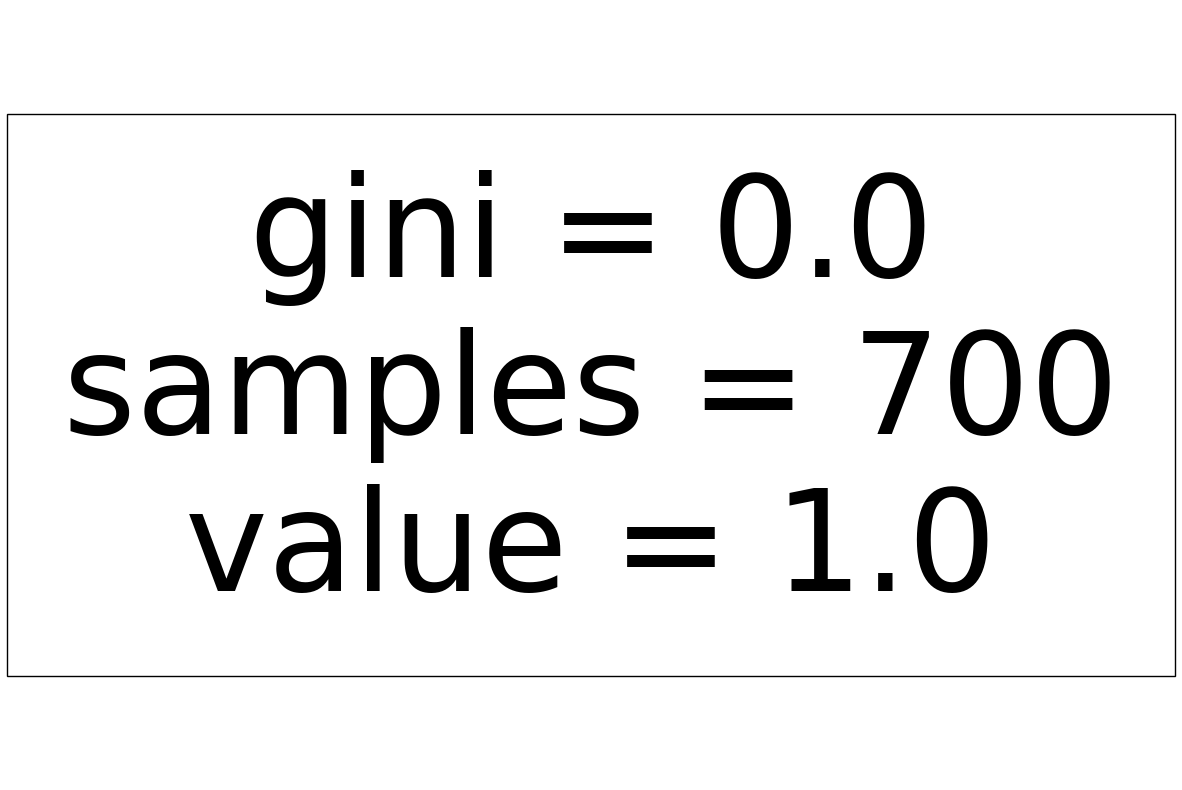

In [ ]:
import matplotlib.pyplot as plt
from sklearn import tree
plt.figure(figsize=(15,10))
tree.plot_tree(humidity_classifier,filled=True)

In [ ]:
y_pred=humidity_classifier.predict(X_test)
print(y_pred)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1]


In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score,classification_report

In [ ]:
print(confusion_matrix  (y_test,y_pred))

[[300]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [ ]:
accuracy=accuracy_score(y_test,y_pred)
print(accuracy)

1.0


In [ ]:
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00       300

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300

